# Mutual Fund Analytics

## NAV Trend Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
plt.style.use("ggplot")

In [3]:
nav_df = pd.read_csv("../Data/Processed/clean_nav_history.csv")


In [5]:
nav_df.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav_df.shape

(46000, 3)

In [7]:
nav_df.dtypes

amfi_code      int64
date          object
nav          float64
dtype: object

In [9]:
nav_df["amfi_code"].nunique()

40

In [10]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [13]:
fig = px.line(
    nav_df,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of 40 Mutual Fund Schemes (2022–2026)",
    labels={
        "date": "Date",
        "nav": "Net Asset Value (NAV)",
        "amfi_code": "AMFI Code"
    }
)

# Highlight 2023 Bull Run
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="lightgreen",
    opacity=0.2,
    annotation_text="2023 Bull Run",
    annotation_position="top left",
    line_width=0
)

# Highlight 2024 Market Correction
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="lightcoral",
    opacity=0.2,
    annotation_text="2024 Market Correction",
    annotation_position="top left",
    line_width=0
)

fig.update_layout(
    template="plotly_white",
    width=1200,
    height=700,
    title_x=0.5
)

fig.show()

In [14]:
fig.write_image("../Report/nav_trend_all_schemes.png")

## Insight 1

The daily NAV trend shows that most of the mutual fund schemes experienced long-term growth between 2022 and 2026, with a noticeable market fluctuation. The highlighted 2023 period reflects a broad market rally, while the highlighted 2024 period shows increased market volatility and correction across multiple schemes.

In [16]:
aum_df = pd.read_csv("../Data/Raw/03_aum_by_fund_house.csv")

In [17]:
aum_df.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [18]:
aum_df.dtypes

date               object
fund_house         object
aum_lakh_crore    float64
aum_crore           int64
num_schemes         int64
dtype: object

In [19]:
aum_df["date"] = pd.to_datetime(aum_df["date"])

In [20]:
aum_df.info

<bound method DataFrame.info of          date                fund_house  aum_lakh_crore  aum_crore  \
0  2022-03-31           SBI Mutual Fund            6.05     605000   
1  2022-03-31       ICICI Prudential MF            4.65     465000   
2  2022-03-31          HDFC Mutual Fund            4.35     435000   
3  2022-03-31           Nippon India MF            2.70     270000   
4  2022-03-31         Kotak Mahindra MF            2.70     270000   
..        ...                       ...             ...        ...   
85 2025-12-31  Aditya Birla Sun Life MF            4.60     460000   
86 2025-12-31          Axis Mutual Fund            3.50     350000   
87 2025-12-31           UTI Mutual Fund            4.10     410000   
88 2025-12-31            Mirae Asset MF            2.90     290000   
89 2025-12-31           DSP Mutual Fund            2.30     230000   

    num_schemes  
0           186  
1           216  
2           195  
3           177  
4           168  
..          ...  
8

In [21]:
aum_df.shape

(90, 5)

In [22]:
aum_df["year"] = aum_df["date"].dt.year

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
aum_df[aum_df["fund_house"] == "SBI Mutual Fund"]

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
10,2022-09-30,SBI Mutual Fund,6.30,630000,186,2022
20,2023-03-31,SBI Mutual Fund,7.17,717000,186,2023
30,2023-09-30,SBI Mutual Fund,8.45,845000,186,2023
40,2024-03-31,SBI Mutual Fund,10.00,1000000,186,2024
50,2024-09-30,SBI Mutual Fund,10.80,1080000,186,2024
60,2024-12-31,SBI Mutual Fund,11.14,1114000,186,2024
70,2025-03-31,SBI Mutual Fund,12.50,1250000,186,2025
80,2025-12-31,SBI Mutual Fund,12.50,1250000,186,2025


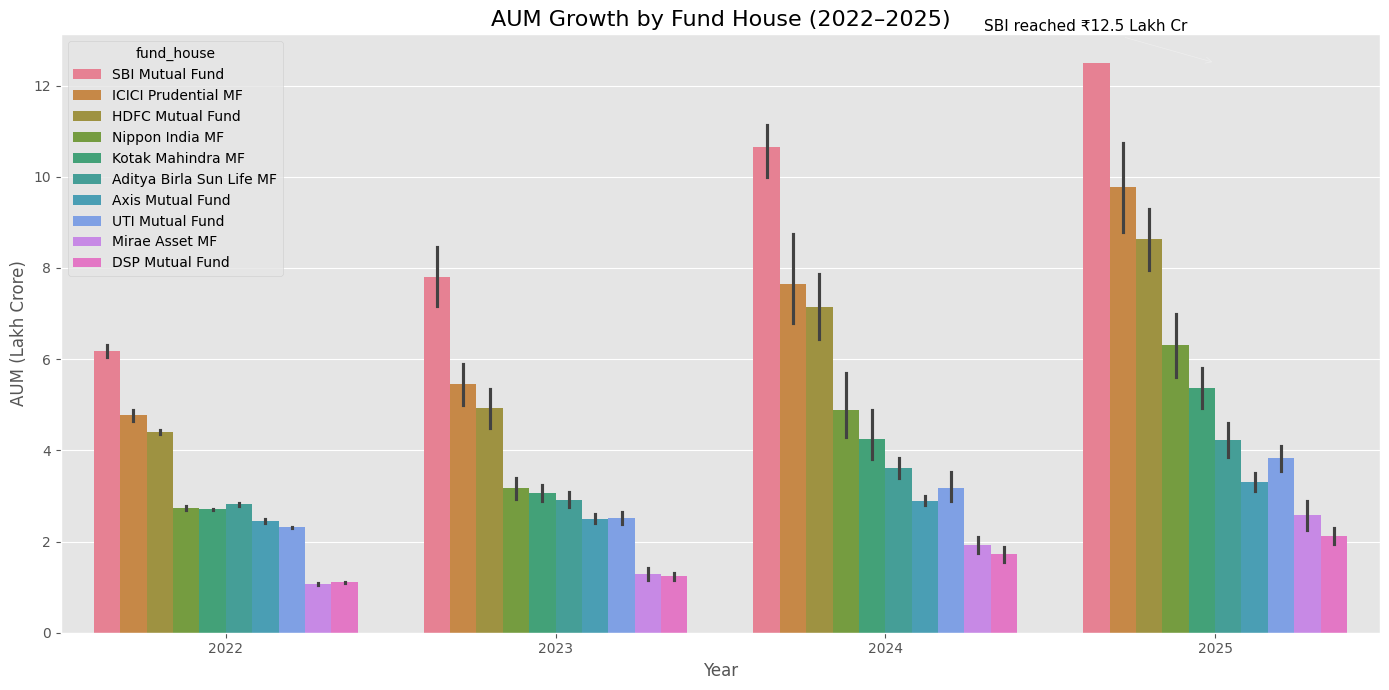

In [25]:
plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=aum_df,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

# Highlight SBI's peak AUM
plt.annotate(
    "SBI reached ₹12.5 Lakh Cr",
    xy=(3, 12.5),          # 2025 position
    xytext=(2.3, 13.2),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

plt.tight_layout()
plt.show()

In [26]:
plt.savefig("../Report/aum_growth.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Insight 2

SBI Mutual Fund showed consistent AUM growth from **₹6.05 lakh crore in 2022** to **₹12.50 lakh crore in 2025**, which made it the largest fund house in the dataset. This reflected strong investor confidence and sustained an asset growth over period of 4 years.

In [27]:
sip_df = pd.read_csv("../Data/Raw/04_monthly_sip_inflows.csv")

In [28]:
sip_df.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [29]:
sip_df.info

<bound method DataFrame.info of       month  sip_inflow_crore  active_sip_accounts_crore  \
0   2022-01             11517                       4.91   
1   2022-02             11438                       4.93   
2   2022-03             12328                       5.09   
3   2022-04             11863                       5.48   
4   2022-05             12286                       5.55   
5   2022-06             12276                       5.60   
6   2022-07             12140                       5.65   
7   2022-08             12694                       5.71   
8   2022-09             12976                       5.80   
9   2022-10             13040                       5.93   
10  2022-11             13306                       6.00   
11  2022-12             13573                       6.05   
12  2023-01             13856                       6.13   
13  2023-02             13687                       6.19   
14  2023-03             14276                       6.32   
15  2023

In [30]:
sip_df["month"] = pd.to_datetime(sip_df["month"])

In [31]:
sip_df.dtypes

month                        datetime64[ns]
sip_inflow_crore                      int64
active_sip_accounts_crore           float64
new_sip_accounts_lakh               float64
sip_aum_lakh_crore                  float64
yoy_growth_pct                      float64
dtype: object

In [32]:
sip_df.loc[sip_df["sip_inflow_crore"].idxmax()]

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object

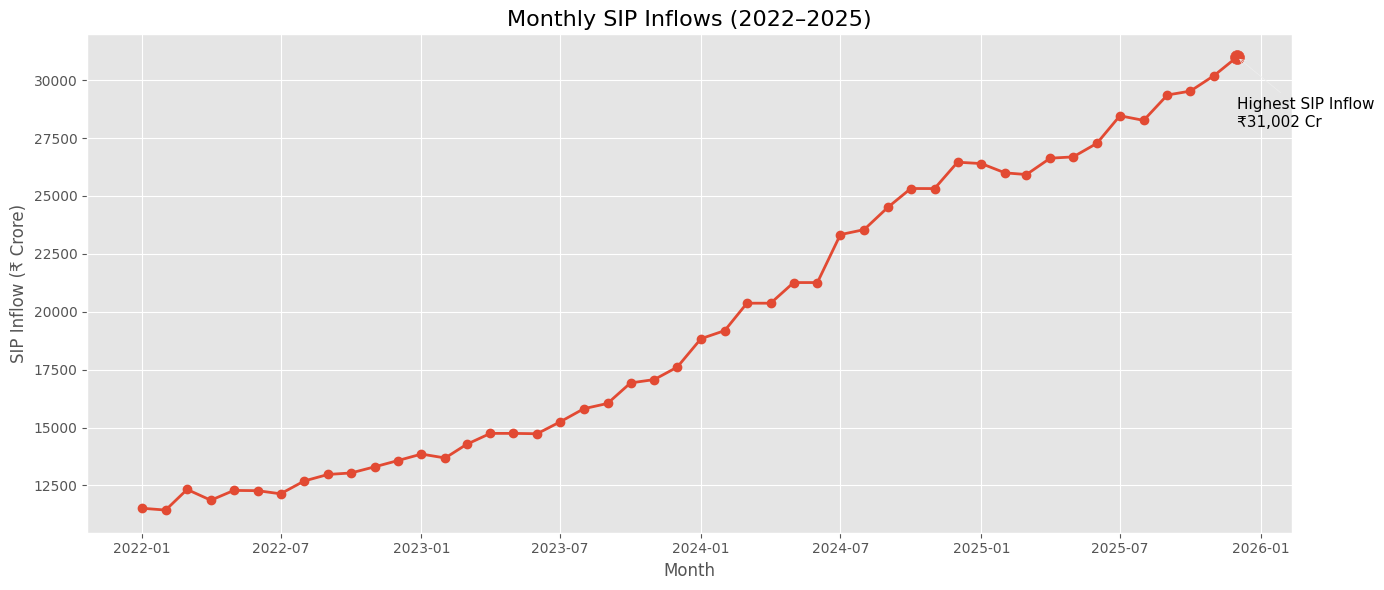

In [33]:
plt.figure(figsize=(14,6))

plt.plot(
    sip_df["month"],
    sip_df["sip_inflow_crore"],
    marker="o",
    linewidth=2
)

plt.title("Monthly SIP Inflows (2022–2025)", fontsize=16)
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")

# Highlight highest SIP inflow
plt.scatter(
    sip_df.loc[sip_df["sip_inflow_crore"].idxmax(), "month"],
    sip_df["sip_inflow_crore"].max(),
    s=100
)

plt.annotate(
    "Highest SIP Inflow\n₹31,002 Cr",
    xy=(
        sip_df.loc[sip_df["sip_inflow_crore"].idxmax(), "month"],
        sip_df["sip_inflow_crore"].max()
    ),
    xytext=(
        sip_df.loc[sip_df["sip_inflow_crore"].idxmax(), "month"],
        28000
    ),
    arrowprops=dict(arrowstyle="->"),
    fontsize=11
)

plt.grid(True)

plt.tight_layout()

plt.show()

In [34]:
plt.savefig(
    "../Report/monthly_sip_trend.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Insight 3

Monthly SIP inflows increased steadily from 2022 to 2025, reaching a peak of **₹31,002 crore in December 2025**. This suggests growing retail investor participation and increasing confidence in systematic mutual fund investing.

In [35]:
category_df = pd.read_csv("../Data/Raw/05_category_inflows.csv")

In [36]:
category_df.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [37]:
category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   month             144 non-null    object 
 1   category          144 non-null    object 
 2   net_inflow_crore  144 non-null    float64
dtypes: float64(1), object(2)
memory usage: 3.5+ KB


In [38]:
category_df["month"] = pd.to_datetime(category_df["month"])

In [39]:
category_df.dtypes

month               datetime64[ns]
category                    object
net_inflow_crore           float64
dtype: object

In [42]:
category_pivot = category_df.pivot(
    index="month",
    columns="category",
    values="net_inflow_crore"
)


In [43]:
category_pivot.head()

category,ELSS,Flexi Cap,Gilt,Hybrid,Large & Mid Cap,Large Cap,Liquid,Mid Cap,Sectoral/Thematic,Short Duration,Small Cap,Value/Contra
month,,,,,,,,,,,,
2024-04-01,466.0,4947.0,784.0,2955.0,4214.0,2413.0,37537.0,3897.0,8052.0,4400.0,3533.0,1328.0
2024-05-01,553.0,5529.0,836.0,3487.0,4368.0,2076.0,41872.0,5300.0,8354.0,4833.0,4092.0,1361.0
2024-06-01,472.0,4478.0,864.0,3163.0,4610.0,2519.0,40486.0,5047.0,10030.0,4321.0,3535.0,1386.0
2024-07-01,471.0,4869.0,959.0,3291.0,5023.0,2574.0,34643.0,4548.0,9896.0,4170.0,3582.0,1582.0
2024-08-01,499.0,5562.0,952.0,3684.0,5411.0,1940.0,41952.0,3899.0,8360.0,4658.0,3376.0,1308.0


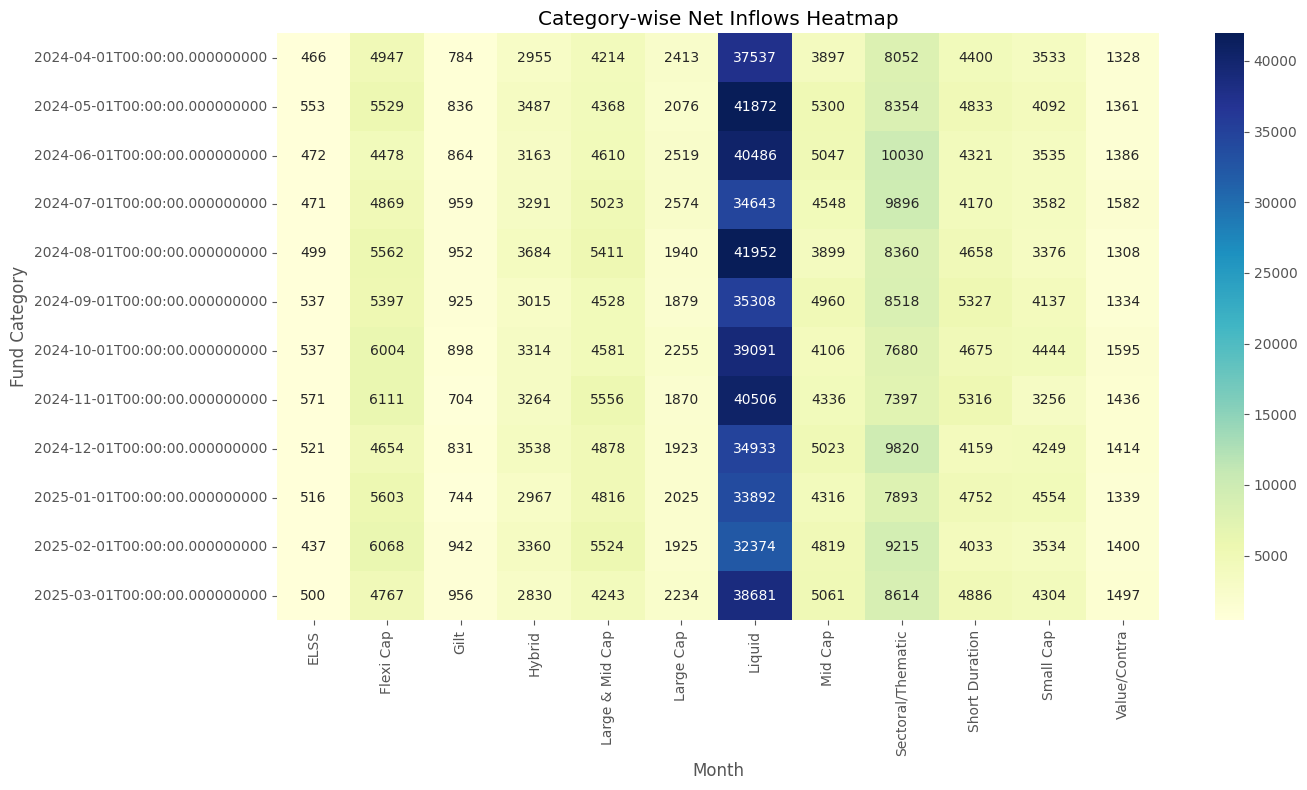

In [46]:
plt.figure(figsize=(14,8))

sns.heatmap(
    category_pivot,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()

plt.show()  

In [47]:
plt.tight_layout()

plt.savefig(
    "../Report/category_inflow_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

## Insight 4

The heatmap highlights monthly investment patterns across mutual fund categories. Darker cells indicate months with higher net inflows, helping identify which categories consistently attracted investor interest and which experienced lower participation over time.

In [49]:
investor_df = pd.read_csv("../Data/Raw/08_investor_transactions.csv")

In [52]:
pd.set_option("display.max_columns", None)

In [53]:
investor_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [54]:
investor_df.info

<bound method DataFrame.info of       investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0       INV003054       2024-01-01     119092              SIP        1834   
1       INV002952       2024-01-01     148567       Redemption      392882   
2       INV003420       2024-01-01     118636              SIP         912   
3       INV003436       2024-01-01     118634              SIP        1102   
4       INV004691       2024-01-01     119094          Lumpsum        8682   
...           ...              ...        ...              ...         ...   
32773   INV003340       2025-05-30     101207          Lumpsum      168029   
32774   INV001838       2025-05-30     119093              SIP        2175   
32775   INV000074       2025-05-30     120504              SIP       25998   
32776   INV002929       2025-05-30     148568              SIP         459   
32777   INV001852       2025-05-30     118633       Redemption      226721   

                state       cit

In [55]:
age_counts = investor_df["age_group"].value_counts()
age_counts

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

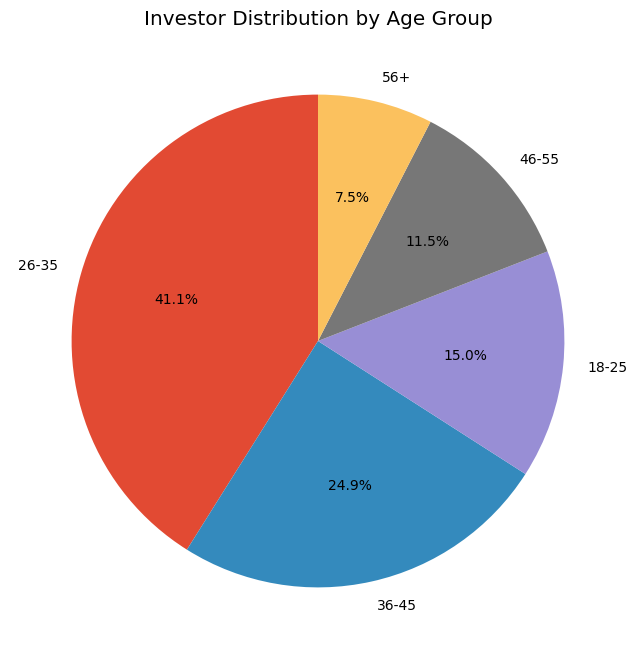

In [56]:
plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by Age Group")

plt.show()

In [57]:
plt.savefig(
    "../Report/investor_age_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

## Insight 5

The age distribution chart shows which age groups contribute the largest share of mutual fund investors. This helps identify the primary target audience for investment products and marketing campaigns.

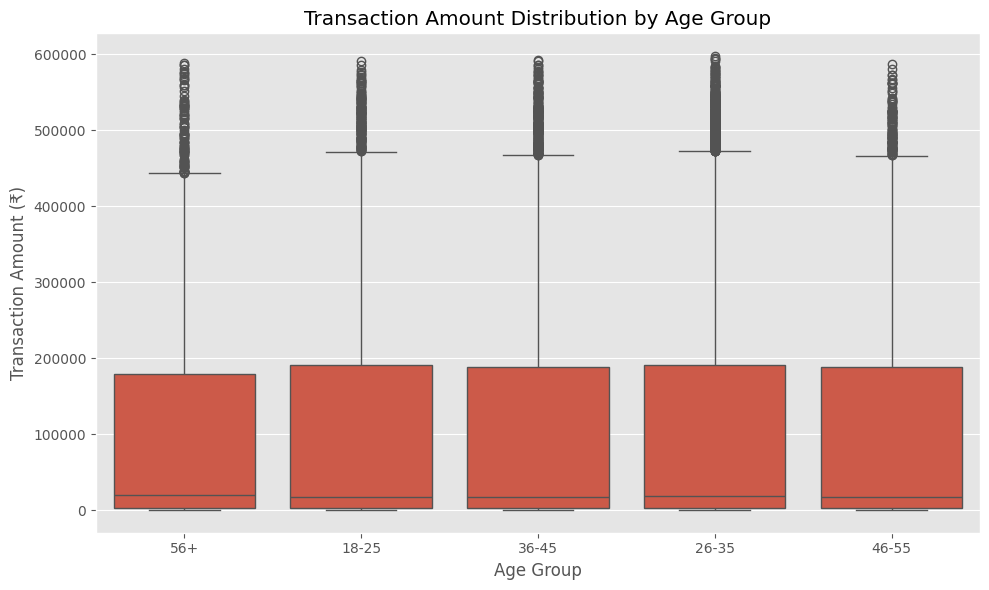

In [58]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor_df,
    x="age_group",
    y="amount_inr"
)

plt.title("Transaction Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Transaction Amount (₹)")

plt.tight_layout()

plt.show()

In [59]:
plt.savefig(
    "../Report/sip_amount_boxplot_age.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Insight 6

The box plot compares transaction amount distributions across age groups. It helps identify which age groups have higher median investment amounts and whether certain groups exhibit greater variability or high-value outlier investments.

In [60]:
gender_counts = investor_df["gender"].value_counts()
gender_counts

gender
Male      21809
Female    10969
Name: count, dtype: int64

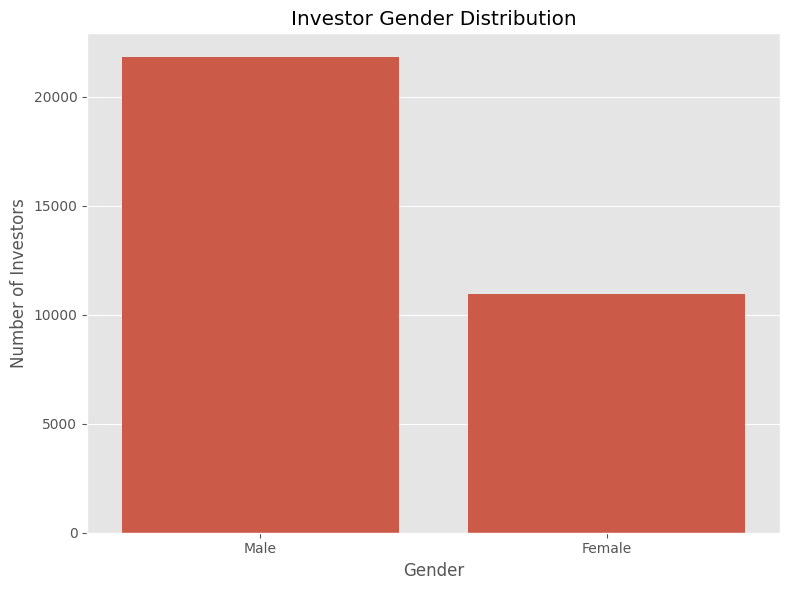

In [61]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title("Investor Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.tight_layout()

plt.show()

In [62]:
plt.savefig(
    "../Report/gender_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Insight 7

The gender distribution chart highlights the proportion of male and female investors. Understanding this distribution helps organizations evaluate investor diversity and tailor financial awareness or product strategies accordingly.

In [63]:
investor_df = pd.read_csv("../Data/Raw/08_investor_transactions.csv")

In [64]:
investor_df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [65]:
investor_df.info

<bound method DataFrame.info of       investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0       INV003054       2024-01-01     119092              SIP        1834   
1       INV002952       2024-01-01     148567       Redemption      392882   
2       INV003420       2024-01-01     118636              SIP         912   
3       INV003436       2024-01-01     118634              SIP        1102   
4       INV004691       2024-01-01     119094          Lumpsum        8682   
...           ...              ...        ...              ...         ...   
32773   INV003340       2025-05-30     101207          Lumpsum      168029   
32774   INV001838       2025-05-30     119093              SIP        2175   
32775   INV000074       2025-05-30     120504              SIP       25998   
32776   INV002929       2025-05-30     148568              SIP         459   
32777   INV001852       2025-05-30     118633       Redemption      226721   

                state       cit

In [66]:
state_sip = investor_df.groupby("state")["amount_inr"].sum()

In [67]:
state_sip = state_sip.sort_values(ascending=False)

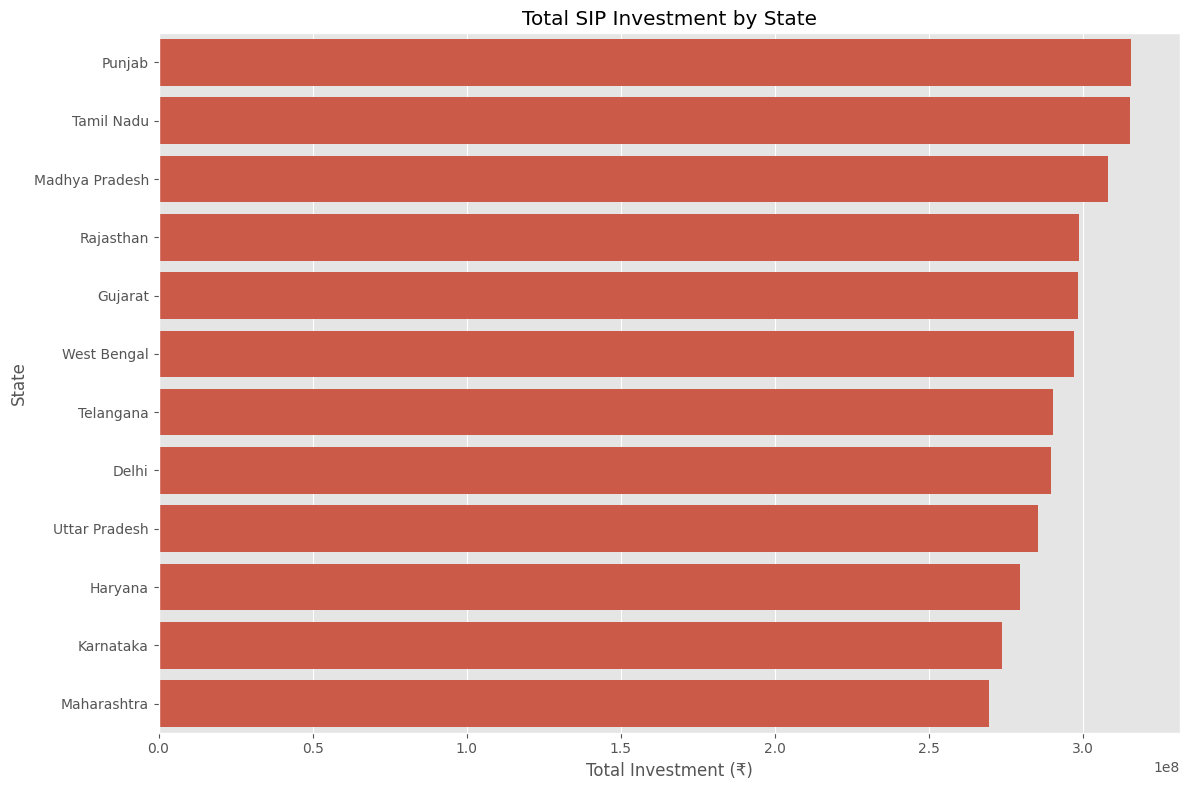

In [68]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title("Total SIP Investment by State")
plt.xlabel("Total Investment (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.show()

In [69]:
plt.savefig(
    "../Report/state_sip_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Insight 8

The horizontal bar chart shows the total investment amount contributed by each state. States with the highest investment indicate stronger mutual fund participation and can help identify key regional markets for financial institutions.

In [70]:
city_counts = investor_df["city_tier"].value_counts()

city_counts

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

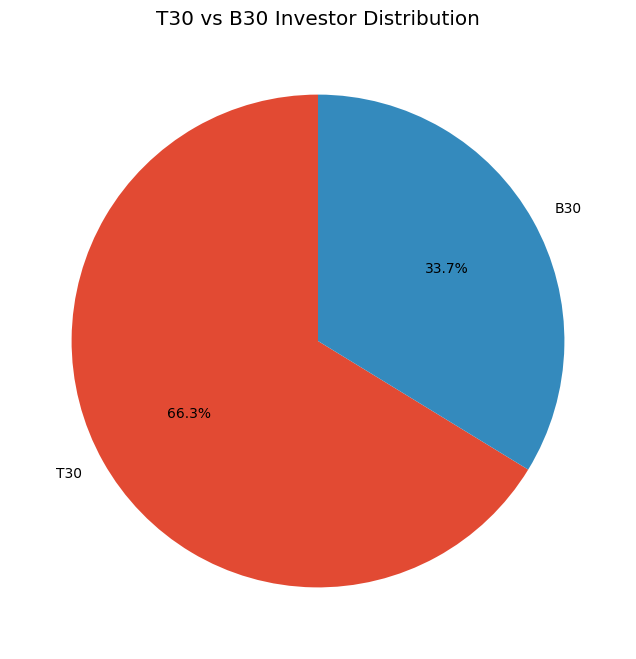

In [71]:

plt.figure(figsize=(8,8))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("T30 vs B30 Investor Distribution")

plt.show()

In [72]:
plt.savefig(
    "../Report/t30_b30_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Insight 9

The T30 vs B30 pie chart compares investor participation across metropolitan and non-metropolitan regions. This helps understand whether mutual fund investments are concentrated in large cities or are expanding into smaller towns.

In [73]:
folio_df = pd.read_csv("../Data/Raw/06_industry_folio_count.csv")

In [74]:
folio_df.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [75]:
folio_df.info

<bound method DataFrame.info of       month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0   2022-01               13.26                 9.28               1.86   
1   2022-04               13.91                 9.74               1.95   
2   2022-07               13.85                 9.69               1.94   
3   2022-10               14.12                 9.88               1.98   
4   2023-01               14.81                10.37               2.07   
5   2023-04               15.54                10.88               2.18   
6   2023-07               16.28                11.40               2.28   
7   2023-10               16.72                11.70               2.34   
8   2024-01               17.78                12.45               2.49   
9   2024-04               18.85                13.20               2.64   
10  2024-07               19.98                13.99               2.80   
11  2024-10               21.62                15.13               3

In [76]:
folio_df["month"] = pd.to_datetime(folio_df["month"])

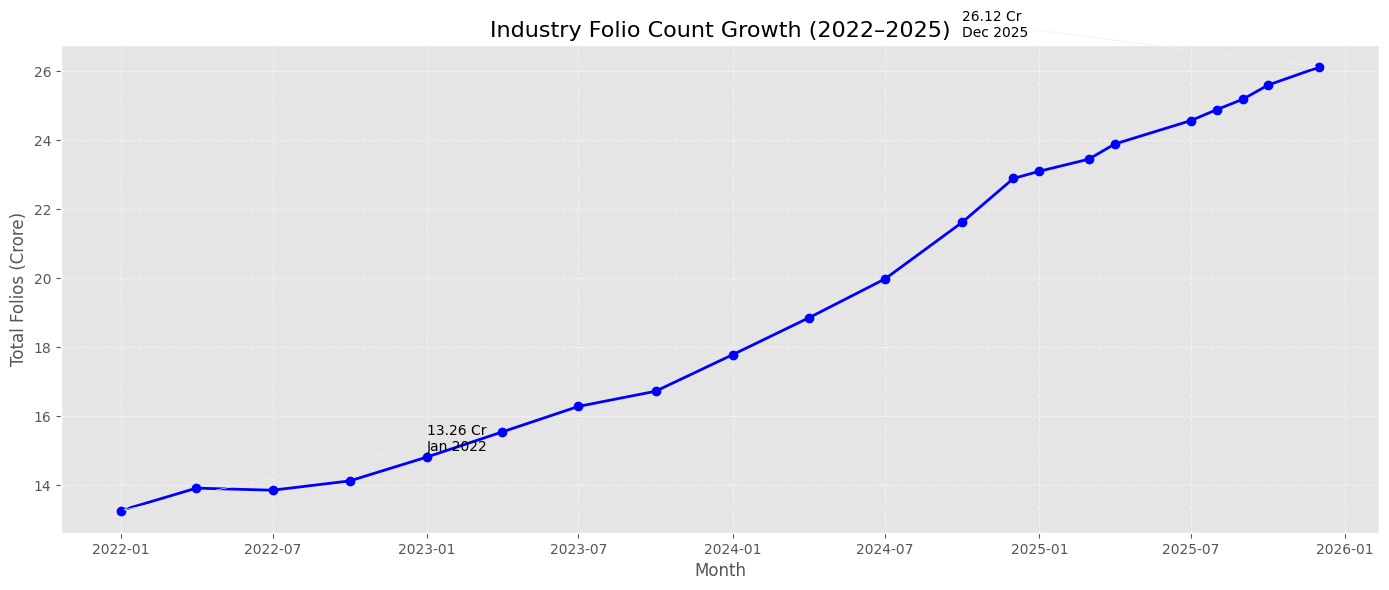

In [81]:

# Create Figure
plt.figure(figsize=(14,6))

# Plot Line Chart
plt.plot(
    folio_df["month"],
    folio_df["total_folios_crore"],
    marker="o",
    linewidth=2,
    color="blue"
)

# Chart Title
plt.title(
    "Industry Folio Count Growth (2022–2025)",
    fontsize=16
)

# Axis Labels
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

# Grid
plt.grid(True, linestyle="--", alpha=0.5)

# Starting Milestone
plt.annotate(
    "13.26 Cr\nJan 2022",
    xy=(
        folio_df["month"].iloc[0],
        folio_df["total_folios_crore"].iloc[0]
    ),
    xytext=(
        folio_df["month"].iloc[4],
        15
    ),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Ending Milestone
plt.annotate(
    "26.12 Cr\nDec 2025",
    xy=(
        folio_df["month"].iloc[-1],
        folio_df["total_folios_crore"].iloc[-1]
    ),
    xytext=(
        folio_df["month"].iloc[-10],
        27
    ),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Layout
plt.tight_layout()

# Show Chart
plt.show()

In [82]:
# Save Chart
plt.savefig(
    "../Report/folio_count_growth.png",
    dpi=300,
    bbox_inches="tight"
)


<Figure size 640x480 with 0 Axes>

## Insight 10

The total mutual fund folio count increased steadily from **13.26 crore in January 2022** to **26.12 crore in December 2025**, indicating strong growth in retail investor participation. This upward trend reflects increasing awareness and adoption of mutual fund investments across the country.

In [83]:
nav_df = pd.read_csv("../Data/Raw/02_nav_history.csv")

In [84]:
nav_df.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [85]:
nav_df.info


<bound method DataFrame.info of        amfi_code        date       nav
0         119551  2022-01-03   54.3856
1         119551  2022-01-04   54.3474
2         119551  2022-01-05   54.6869
3         119551  2022-01-06   55.4550
4         119551  2022-01-07   55.3692
...          ...         ...       ...
45995     149324  2026-05-25  292.4810
45996     149324  2026-05-26  291.2707
45997     149324  2026-05-27  288.8007
45998     149324  2026-05-28  280.6873
45999     149324  2026-05-29  279.7511

[46000 rows x 3 columns]>

In [87]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

In [88]:
selected_funds = nav_df["amfi_code"].unique()[:10]

selected_funds

array([119551, 119552, 119598, 119599, 119120, 100016, 125497, 100033,
       125498, 100025])

In [89]:
nav_10 = nav_df[
    nav_df["amfi_code"].isin(selected_funds)
]

In [90]:
nav_pivot = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

In [91]:
returns = nav_pivot.pct_change()

In [92]:
correlation_matrix = returns.corr()

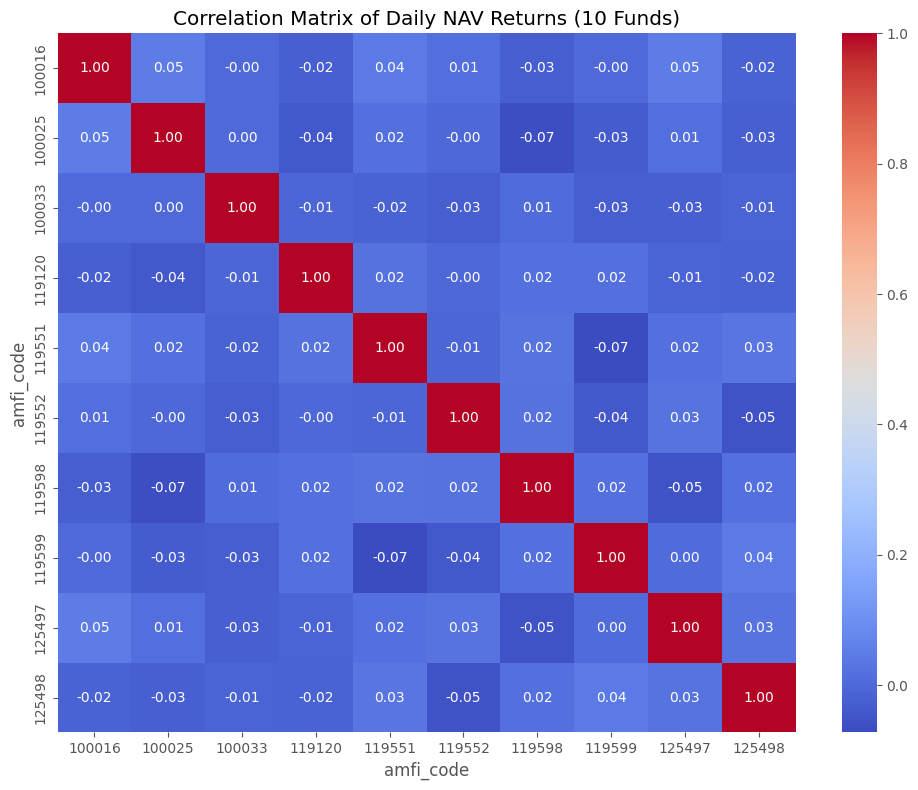

In [93]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Daily NAV Returns (10 Funds)")

plt.tight_layout()

In [94]:
plt.savefig(
    "../Report/nav_return_correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

## Insight 11

The correlation matrix shows the relationship between daily NAV returns of 10 selected mutual funds. Darker red cells indicate strong positive correlation, suggesting that those funds tend to move together. Lower or negative correlations indicate greater diversification potential for investors.

In [96]:
portfolio_df = pd.read_csv("../Data/Raw/09_portfolio_holdings.csv")

In [97]:
portfolio_df.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [98]:
portfolio_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    object 
 2   stock_name         322 non-null    object 
 3   sector             322 non-null    object 
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    object 
dtypes: float64(3), int64(1), object(4)
memory usage: 20.3+ KB


In [99]:
portfolio_df.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [100]:
sector_weights = (
    portfolio_df
    .groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

In [101]:
sector_weights

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

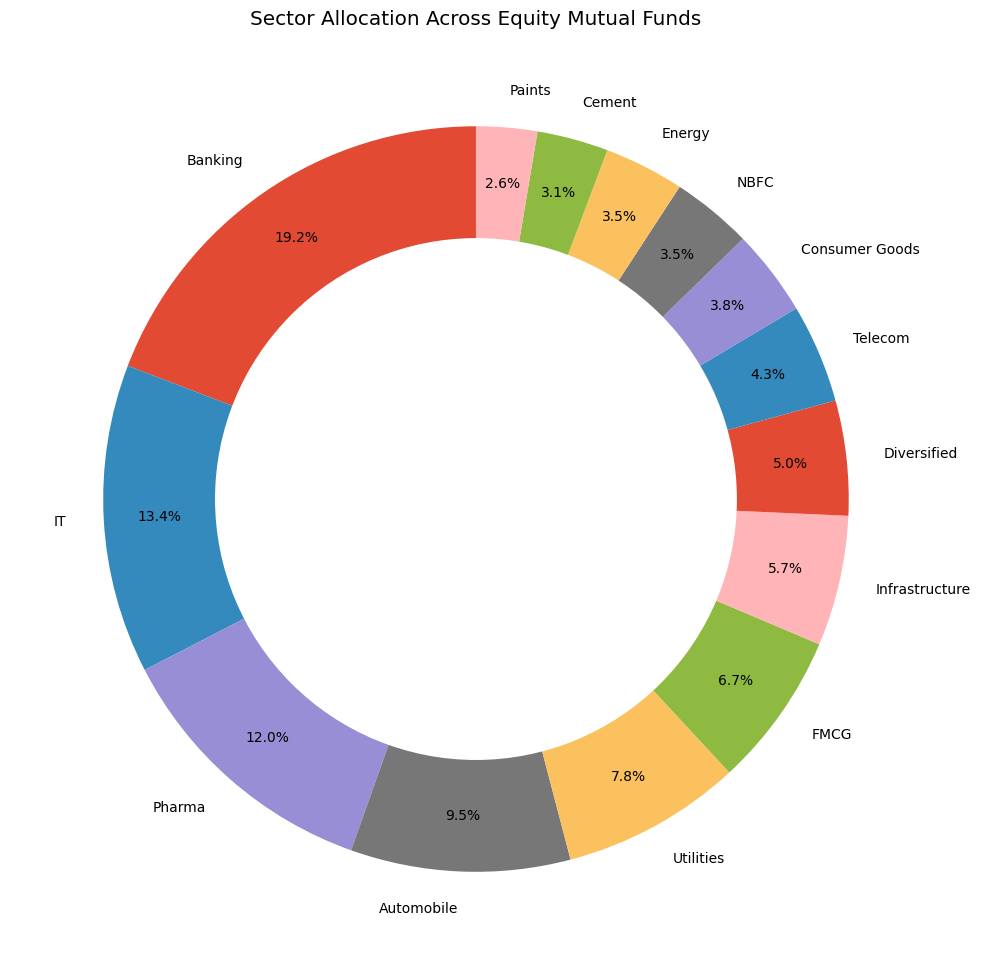

In [102]:
plt.figure(figsize=(10,10))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.85
)

centre_circle = plt.Circle((0,0),0.70,fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Mutual Funds")

plt.tight_layout()

plt.savefig(
    "../Report/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [103]:
plt.savefig(
    "../Report/sector_allocation_donut.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

## Insight 12

The donut chart summarizes sector allocation across all equity mutual funds. Sectors with the largest share indicate where fund managers have concentrated their investments, while smaller allocations represent comparatively lower portfolio exposure.

In [104]:
performance_df = pd.read_csv("../Data/Raw/07_scheme_performance.csv")

In [105]:
performance_df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [106]:
performance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     object 
 2   fund_house          40 non-null     object 
 3   category            40 non-null     object 
 4   plan                40 non-null     object 
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_ra

In [108]:
top10 = performance_df.nlargest(
    10,
    "return_5yr_pct"
)
top10

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,Regular,21.97,20.98,22.62,20.47,0.51,1.00,0.84,1.40,25.0,-14.45,21545,1.38,4,Very High
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India MF,Small Cap,Regular,21.30,20.15,21.88,19.35,0.80,1.03,0.81,1.14,25.0,-30.87,43630,1.53,4,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
39,149324,DSP Small Cap Fund - Regular - Growth,DSP Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,0.98,0.80,1.23,25.0,-17.01,35124,1.52,4,Very High
38,149323,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,0.98,0.90,1.50,19.0,-26.99,37835,1.61,4,High
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,1.00,0.80,1.18,19.0,-32.38,28996,1.38,5,High
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,0.91,0.87,1.44,19.0,-13.67,23185,1.38,5,High


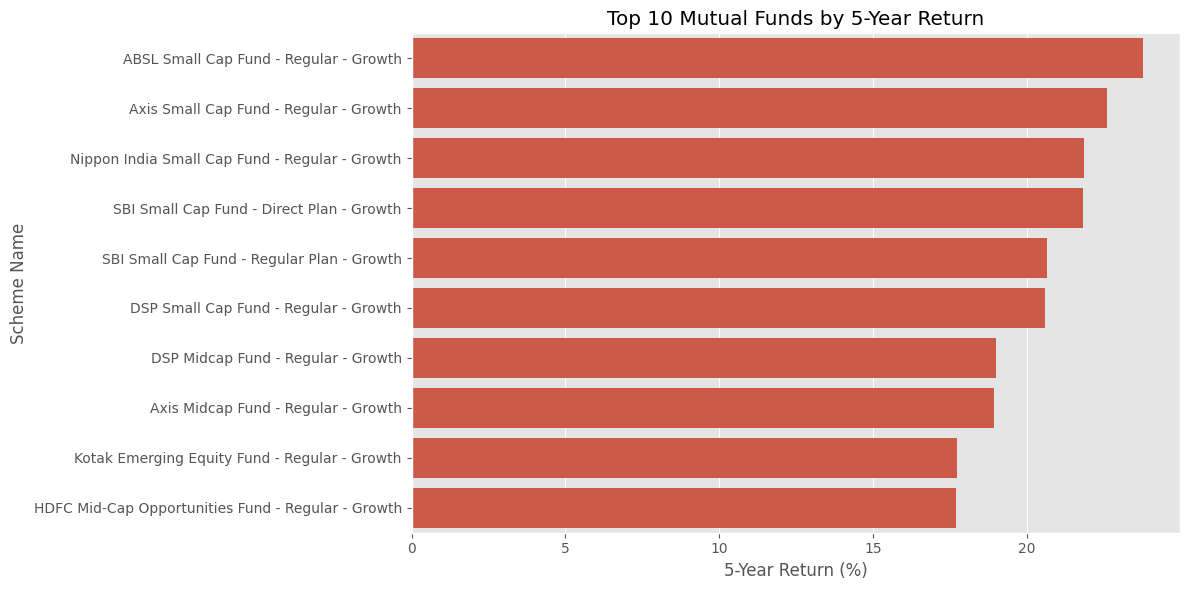

In [109]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds by 5-Year Return")
plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(
    "../Report/top10_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 13

The top 10 mutual funds generated the highest five-year returns, demonstrating strong long-term performance and providing investors with potential high-growth investment opportunities.

**Supporting Chart:** Figure 13 – Top 10 Mutual Funds by 5-Year Return

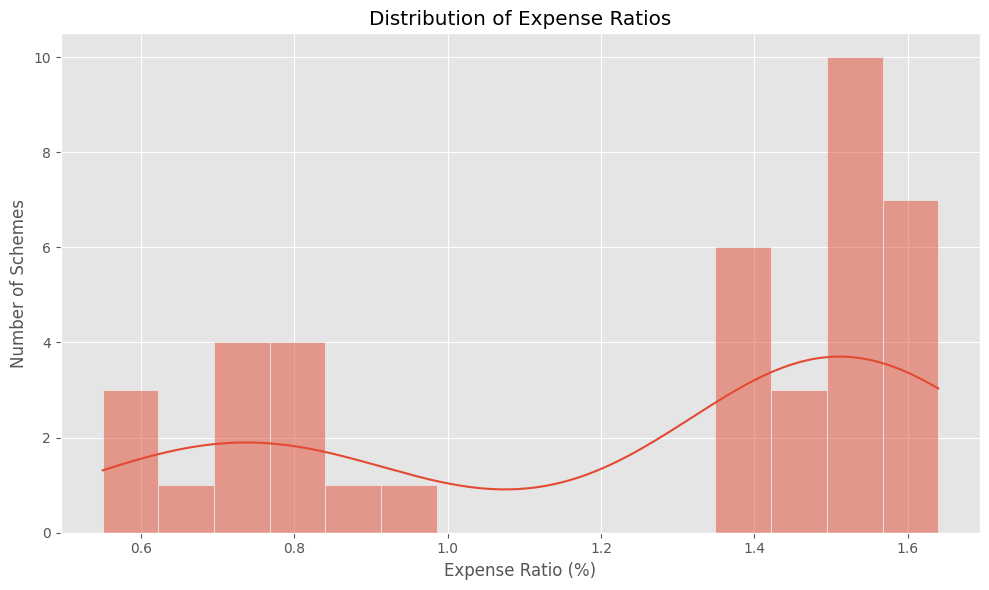

In [111]:
plt.figure(figsize=(10,6))

sns.histplot(
    performance_df["expense_ratio_pct"],
    bins=15,
    kde=True
)

plt.title("Distribution of Expense Ratios")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Schemes")

plt.tight_layout()

plt.savefig(
    "../Report/expense_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 14

Most mutual fund schemes have expense ratios concentrated within a limited range, indicating relatively consistent management fees across the industry.

**Supporting Chart:** Figure 14 – Expense Ratio Distribution

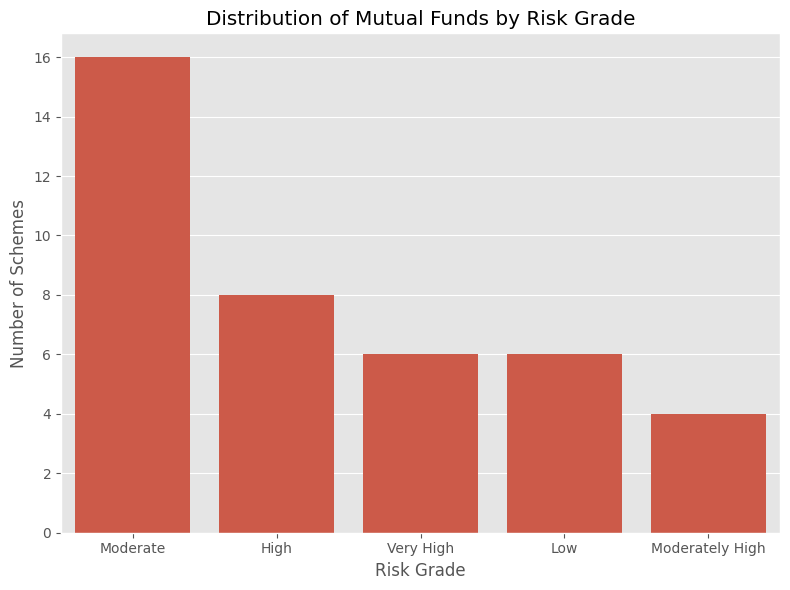

In [112]:
plt.figure(figsize=(8,6))

sns.countplot(
    data=performance_df,
    x="risk_grade",
    order=performance_df["risk_grade"].value_counts().index
)

plt.title("Distribution of Mutual Funds by Risk Grade")
plt.xlabel("Risk Grade")
plt.ylabel("Number of Schemes")

plt.tight_layout()

plt.savefig(
    "../Report/risk_grade_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Insight 15

The majority of mutual fund schemes fall into the High and Very High risk categories, reflecting the equity-focused nature of many investment products.

**Supporting Chart:** Figure 15 – Risk Grade Distribution